In [4]:
import rasterio
import rasterio.features
import os
import numpy as np
os.cpu_count()

32

In [9]:
a = np.array([[1,2,3]])
b = np.array([[1,2,3]])
a.shape == b.shape

True

In [10]:
string_numbers = ["10", "2", "100", "5", "8"]

# Convert each string to an integer for proper numerical sorting
# The 'key' argument in the sort method or sorted() function
# allows you to specify a function to be called on each list item
# prior to making comparisons.
sorted_numbers = sorted(string_numbers, key=int)

print(sorted_numbers)

['2', '5', '8', '10', '100']


(4001, 3001)
(4000, 2992)
(250, 187)


C:\Users\11736\AppData\Local\Temp\ipykernel_14252\4119494364.py:14: RuntimeWarning: Mean of empty slice
  new_res = np.nanmean(new_res,axis=(1,3))


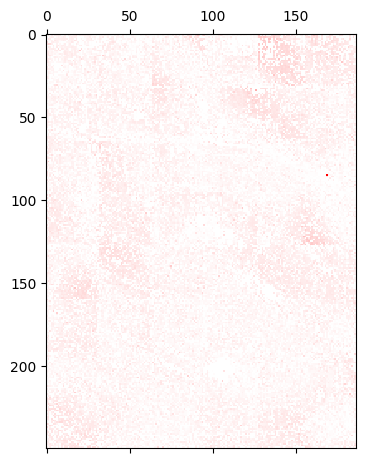

In [1]:
import numpy as np
from matplotlib import pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap
res = np.load('./test_data/match_res/res_1.npy').astype(np.float32)
res[res == 0] = np.nan
H,W = res.shape[:2]
print(res.shape)
H = H // 16 * 16
W = W // 16 * 16
res = res[:H,:W]
print(res.shape)

new_res = res.reshape(H // 16, 16, W // 16, 16)
new_res = np.nanmean(new_res,axis=(1,3))
print(new_res.shape)

colors = [
    (0.,(0,0,0,0)),
    (0.000001,(1,1,1,1)),
    (1.,(1,0,0,1))
]
cmap = LinearSegmentedColormap.from_list("123",colors,N=256)

plt.matshow(new_res,cmap=cmap)

In [11]:
a = np.array([1,2,np.nan,3])
a > 1

array([False,  True, False,  True])

In [12]:
import torch
a = torch.tensor([1,2,3])
torch.roll(a,1)

tensor([3, 1, 2])

In [16]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(10, 20)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(20, 30)

    def forward(self, x):
        return self.linear2(self.relu(self.linear1(x)))

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(30, 20)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(20, 10)

    def forward(self, x):
        return self.linear2(self.relu(self.linear1(x)))

# 实例化模型
encoder = Encoder()
decoder = Decoder()

# 示例输入
input_data = torch.randn(1, 10) # 批大小1，特征10

# 优化器（你需要为编码器和解码器分别创建，或者将它们都加入一个优化器）
# 这里为了演示，我们只关注梯度计算
optimizer_encoder = torch.optim.SGD(encoder.parameters(), lr=0.01)
optimizer_decoder = torch.optim.SGD(decoder.parameters(), lr=0.01)

# --- 正常的损失计算 ---
encoder_output_normal = encoder(input_data)
decoder_output_normal = decoder(encoder_output_normal)
# 假设有一个正常的损失，需要计算所有梯度
target_normal = torch.randn(1, 10)
loss_all_gradients = torch.mean((decoder_output_normal - target_normal)**2)

# 清零梯度
optimizer_encoder.zero_grad()
optimizer_decoder.zero_grad()

# 反向传播
loss_all_gradients.backward()

print("--- 正常损失回传（encoder和decoder都有梯度）---")
for name, param in encoder.named_parameters():
    if param.grad is not None:
        print(f"Encoder param {name} grad sum: {param.grad.sum().item():.4f}")
for name, param in decoder.named_parameters():
    if param.grad is not None:
        print(f"Decoder param {name} grad sum: {param.grad.sum().item():.4f}")

# --- 仅计算encoder梯度的损失 ---
encoder_output = encoder(input_data)
# 关键一步：使用 detach()
# decoder_input_for_encoder_loss = encoder_output_detached.detach()
decoder.requires_grad_(False)
decoder_output_encoder_only_loss = decoder(encoder_output)
decoder.requires_grad_(True)

# 假设这是你希望只计算编码器梯度的损失
target_encoder_only = torch.randn(1, 10)
loss_encoder_only = torch.mean((decoder_output_encoder_only_loss - target_encoder_only)**2)

# 清零梯度
optimizer_encoder.zero_grad()
optimizer_decoder.zero_grad()

# 反向传播
loss_encoder_only.backward()

print("\n--- 仅计算encoder梯度的损失回传（decoder无梯度）---")
for name, param in encoder.named_parameters():
    if param.grad is not None:
        print(f"Encoder param {name} grad sum: {param.grad.sum().item():.4f}")
    else:
        print(f"Encoder param {name} grad: None") # 理论上encoder会有梯度
for name, param in decoder.named_parameters():
    if param.grad is not None:
        print(f"Decoder param {name} grad sum: {param.grad.sum().item():.4f}")
    else:
        print(f"Decoder param {name} grad: None") # Decoder的梯度应该为None或者非常接近0

--- 正常损失回传（encoder和decoder都有梯度）---
Encoder param linear1.weight grad sum: -0.0120
Encoder param linear1.bias grad sum: 0.0141
Encoder param linear2.weight grad sum: -0.7852
Encoder param linear2.bias grad sum: -0.1356
Decoder param linear1.weight grad sum: 0.0040
Decoder param linear1.bias grad sum: 0.2525
Decoder param linear2.weight grad sum: 0.3229
Decoder param linear2.bias grad sum: 0.3624

--- 仅计算encoder梯度的损失回传（decoder无梯度）---
Encoder param linear1.weight grad sum: 0.0768
Encoder param linear1.bias grad sum: -0.0907
Encoder param linear2.weight grad sum: -0.3743
Encoder param linear2.bias grad sum: -0.0646
Decoder param linear1.weight grad: None
Decoder param linear1.bias grad: None
Decoder param linear2.weight grad: None
Decoder param linear2.bias grad: None


In [20]:
torch.stack([torch.tensor(1),torch.tensor(1)])

tensor([1, 1])